# Graph & Page Rank 

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

def load_google_data(file_path):
    df = pd.read_csv(file_path, sep="\t", comment="#", names=["From", "To"])
    print("✅ Jumlah edge:", len(df))
    print("✅ Jumlah node unik:", len(pd.unique(df[['From', 'To']].values.ravel())))
    return df

google_df = load_google_data("/content/web-Google_10k.txt")


✅ Jumlah edge: 78323
✅ Jumlah node unik: 10000


✅ Konvergen pada iterasi ke-58

🔥 5 Node dengan PageRank tertinggi (data bapak):
Node 486980 → PageRank: 0.006999
Node 285814 → PageRank: 0.004748
Node 226374 → PageRank: 0.003396
Node 163075 → PageRank: 0.003331
Node 555924 → PageRank: 0.002686


/tmp/ipython-input-4007595695.py:37: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pr = {nodes[i]: float(p[i]) for i in range(N)}


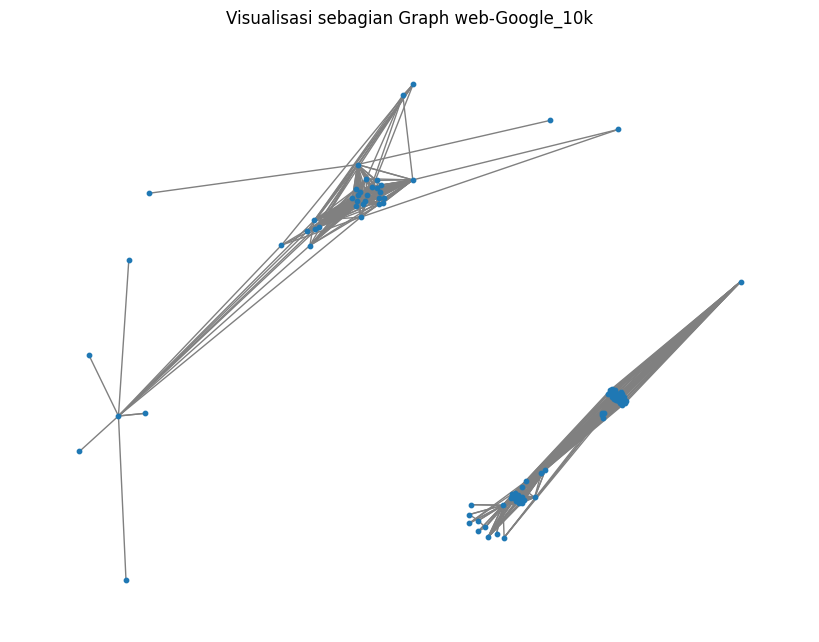

In [ ]:
# IMPLEMENTASI GRAPH, NODE, DAN 5 PAGERANK TERTINGGI

import numpy as np

def pagerank_manual(df, alpha=0.85, tol=1.0e-6, max_iter=100):
    # Bangun graph
    G = nx.DiGraph()
    G.add_edges_from(df.values)
    nodes = list(G.nodes())
    N = len(nodes)
    index = {node: i for i, node in enumerate(nodes)}

    # Matriks transisi M
    M = np.zeros((N, N))
    for j, node in enumerate(nodes):
        out_links = list(G.successors(node))
        if len(out_links) == 0:
            M[:, j] = 1.0 / N  # dangling node
        else:
            for dest in out_links:
                i = index[dest]
                M[i, j] = 1.0 / len(out_links)

    # Inisialisasi vektor PageRank p
    p = np.ones((N, 1)) / N
    teleport = np.ones((N, 1)) / N

    # Iterasi hingga konvergen
    for k in range(max_iter):
        p_new = alpha * (M @ p) + (1 - alpha) * teleport
        if np.linalg.norm(p_new - p, 1) < tol:
            print(f"✅ Konvergen pada iterasi ke-{k}")
            break
        p = p_new

    # Simpan hasil ke dict
    pr = {nodes[i]: float(p[i]) for i in range(N)}

    # Ambil 5 PageRank tertinggi
    top5 = sorted(pr.items(), key=lambda x: x[1], reverse=True)[:5]
    print("\n🔥 5 Node dengan PageRank tertinggi (data bapak):")
    for node, val in top5:
        print(f"Node {node} → PageRank: {val:.6f}")

    # Visualisasi kecil (subset 100 node)
    subG = G.subgraph(list(pr.keys())[:100])
    plt.figure(figsize=(8, 6))
    nx.draw(subG, node_size=10, edge_color="gray", arrows=False)
    plt.title("Visualisasi sebagian Graph web-Google_10k")
    plt.show()
    return G, pr, top5

G_google, google_pr, google_top5 = pagerank_manual(google_df)



In [ ]:
def load_ppw_data(file_path):
    df = pd.read_csv(file_path)
    print(df.head())
    print("✅ Total baris:", len(df))
    return df

ppw_df = load_ppw_data("/content/PPWCrawlingLink (2).csv")


   id                           page                      link_keluar
0   1  https://www2.trunojoyo.ac.id/    https://www2.trunojoyo.ac.id/
1   2  https://www2.trunojoyo.ac.id/    https://www2.trunojoyo.ac.id/
2   3  https://www2.trunojoyo.ac.id/  https://www2.trunojoyo.ac.id/# 
3   4  https://www2.trunojoyo.ac.id/  https://www2.trunojoyo.ac.id/# 
4   5  https://www2.trunojoyo.ac.id/  https://www2.trunojoyo.ac.id/# 
✅ Total baris: 4627


✅ Jumlah node: 4668
✅ Jumlah edge: 4627


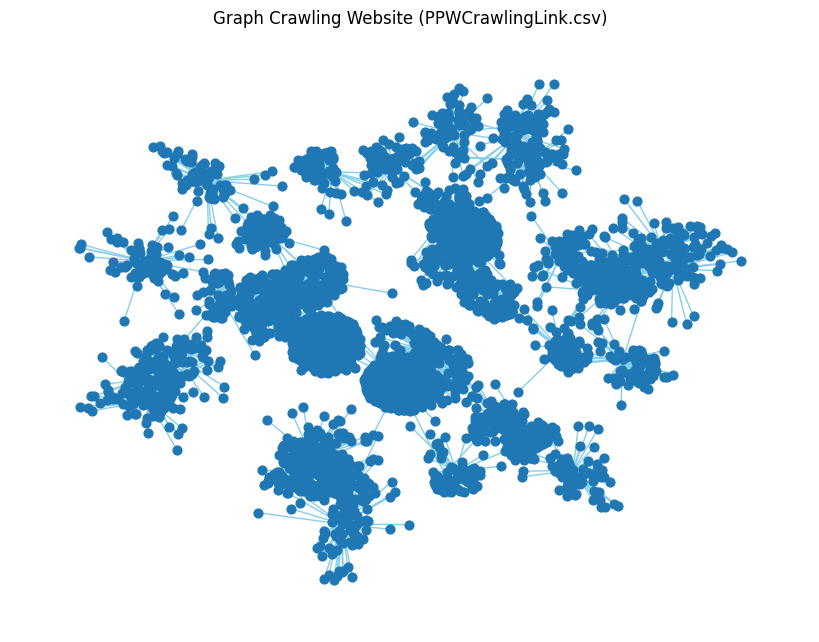

In [ ]:
# MEMBUAT GRAPH & MENAMPILKAN GRAFIKNYA

def build_graph(df):
    # Ambil dua kolom pertama sebagai sumber dan tujuan
    src_col, dst_col = df.columns[:2]
    G = nx.DiGraph()
    G.add_edges_from(df[[src_col, dst_col]].values)
    print(f"✅ Jumlah node: {G.number_of_nodes()}")
    print(f"✅ Jumlah edge: {G.number_of_edges()}")

    # Visualisasi
    plt.figure(figsize=(8,6))
    nx.draw(G, node_size=40, edge_color="skyblue", with_labels=False, arrows=False)
    plt.title("Graph Crawling Website (PPWCrawlingLink.csv)")
    plt.show()
    return G

G_ppw = build_graph(ppw_df)



In [ ]:
# MENENTUKAN NODE PENTING (DEGREE CENTRALITY)

def important_nodes(G):
    deg_centrality = nx.degree_centrality(G)
    top_nodes = sorted(deg_centrality.items(), key=lambda x: x[1], reverse=True)[:5]
    print("🔥 5 Node Paling Penting (Degree Centrality):")
    for node, val in top_nodes:
        print(f"Node {node} → Degree Centrality: {val:.6f}")
    return top_nodes

important_ppw = important_nodes(G_ppw)


🔥 5 Node Paling Penting (Degree Centrality):
Node https://www2.trunojoyo.ac.id/index.php/halinformasi/ → Degree Centrality: 0.121920
Node https://www2.trunojoyo.ac.id/index.php/halber/ → Degree Centrality: 0.116563
Node https://www2.trunojoyo.ac.id/index.php/halaman-kegiatan/ → Degree Centrality: 0.097707
Node https://www2.trunojoyo.ac.id/ → Degree Centrality: 0.025712
Node https://www2.trunojoyo.ac.id/#  → Degree Centrality: 0.025712


✅ Konvergen pada iterasi ke-84

🔥 5 Node dengan PageRank tertinggi (Data Crawling):
Node https://www2.trunojoyo.ac.id/index.php/halinformasi/ → PageRank: 0.056348
Node https://www2.trunojoyo.ac.id/index.php/halber/ → PageRank: 0.053878
Node https://www2.trunojoyo.ac.id/index.php/halaman-kegiatan/ → PageRank: 0.045181
Node https://www2.trunojoyo.ac.id/ → PageRank: 0.011975
Node https://www2.trunojoyo.ac.id/#  → PageRank: 0.011975


/tmp/ipython-input-1998976182.py:28: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pr = {nodes[i]: float(p[i]) for i in range(N)}


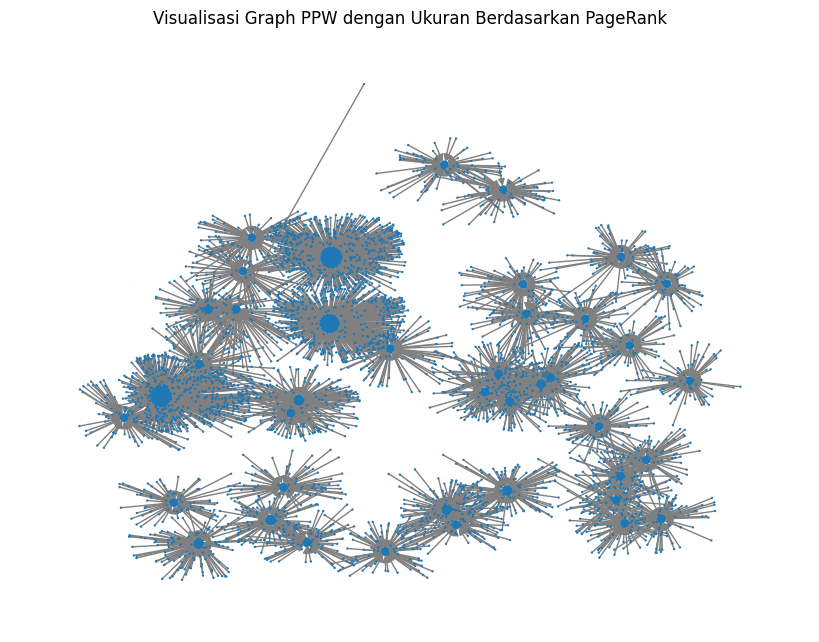

In [ ]:
# MENGHITUNG PAGERANK MANUAL UNTUK DATA CRAWLING

def pagerank_ppw_manual(G, alpha=0.85, tol=1.0e-6, max_iter=100):
    nodes = list(G.nodes())
    N = len(nodes)
    index = {node: i for i, node in enumerate(nodes)}

    M = np.zeros((N, N))
    for j, node in enumerate(nodes):
        out_links = list(G.successors(node))
        if len(out_links) == 0:
            M[:, j] = 1.0 / N
        else:
            for dest in out_links:
                i = index[dest]
                M[i, j] = 1.0 / len(out_links)

    p = np.ones((N, 1)) / N
    teleport = np.ones((N, 1)) / N

    for k in range(max_iter):
        p_new = alpha * (M @ p) + (1 - alpha) * teleport
        if np.linalg.norm(p_new - p, 1) < tol:
            print(f"✅ Konvergen pada iterasi ke-{k}")
            break
        p = p_new

    pr = {nodes[i]: float(p[i]) for i in range(N)}
    top5 = sorted(pr.items(), key=lambda x: x[1], reverse=True)[:5]

    print("\n🔥 5 Node dengan PageRank tertinggi (Data Crawling):")
    for node, val in top5:
        print(f"Node {node} → PageRank: {val:.6f}")

    # Visualisasi kecil
    plt.figure(figsize=(8,6))
    sizes = [pr[n]*4000 for n in G.nodes()]
    nx.draw(G, node_size=sizes, edge_color="gray", with_labels=False)
    plt.title("Visualisasi Graph PPW dengan Ukuran Berdasarkan PageRank")
    plt.show()
    return top5

ppw_top5 = pagerank_ppw_manual(G_ppw)
